In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pingouin as pg
import os
import matplotlib.patches as mpatches

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
import scipy.stats as stats

from myFigures import * 
import gc

from tqdm.notebook import tqdm

# Load and prepare data

In [2]:
PROJECT_PATH = "/media/wiseman/tocho/predrelv_fmri/"
DATA_PATH = f"{PROJECT_PATH}/group_analyses/multivariate/MVPA_proba/analyses/decoding_data/"
ROI = "earlyvisual"
n_voxels = "wholeROI"

df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")

Columns for SDT  
For these analyses we will consider 2 things.  
1 - the type of decision:
> Hit: stimulus EXP and CORRECT decision  
> False alarm: UEX and incorrect  
> Correct rejection: UEX and acorrect  
> Miss: EXP and incorrect

2 - Evidence strength  
For this we will use the signed distance from the hyperplane at each decision


In [3]:
# New distance column
# In the decision_distances column, negative values correspond to CCW decisions and positive values to CW decisions
# For our purpose, these two decisions are equivalent. What we need to consider is wether the choice was expected or not
# To collapse the decisions based on expectation conditions, we will invert the sign of the distance when CCW was expected.
# This way, the distance will always be positive when the decision was expected and negative when it was unexpected

# Let's start by creating a new column with the expected stimulus. This should be equal to the column labels when pred == 1, and the opposite when pred == 0
df["expected_stim"] = np.where(
    df["v_pred"] == 1, 
    df["labels"], 
    np.where(df["labels"] == 45, 135, 45)
)

# Now we can calculate the new distance column. We will invert the sign when 135 was the expected stimulus
df["distance"] = np.where(df["expected_stim"] == 135, -df["decision_distances"], df["decision_distances"])

# Finally for each subject we z score the distances
# Z-normalize `distance` within each subject
df['z_distance'] = df.groupby('subj')['distance'].transform(
    lambda x: (x - x.mean()) / x.std())


In [4]:
# Decision types columns
# Hit column
df["hit"] = np.where(
    (df["correct"] == 1) & (df["v_pred"] == 1), 1, 0
)

df["fa"] = np.where(
    (df["correct"] == 0) & (df["v_pred"] == 0), 1, 0
)

df["CR"] = np.where(
    (df["correct"] == 1) & (df["v_pred"] == 0), 1, 0
)

df["miss"] = np.where(
    (df["correct"] == 0) & (df["v_pred"] == 1), 1, 0
)

In [5]:
# Alternatively, code decision type in a single column
df["decision_type"] = np.where(
    (df["correct"] == 1) & (df["v_pred"] == 1), "hit",
    np.where(
        (df["correct"] == 0) & (df["v_pred"] == 0), "fa",
        np.where(
            (df["correct"] == 1) & (df["v_pred"] == 0), "CR",
            np.where(
                (df["correct"] == 0) & (df["v_pred"] == 1), "miss",
                "error"
            )
        )
    )
)

In [6]:
# New column for signal and noise trials
df["signal_noise"] = np.where(
    (df["decision_type"] == "hit") | (df["decision_type"] == "miss"), "signal",
    np.where(
        (df["decision_type"] == "fa") | (df["decision_type"] == "CR"), "noise",
        "error"
    )
)

## SDT measures

In [7]:
# Function to calculate d' and criterion
from scipy.stats import norm

def compute_dprime(data, signal_col, condition_cols=None):
    """
    Generalized function to compute d' and criterion for given conditions.

    Parameters:
    - data (pd.DataFrame): The input dataframe containing trial data.
    - signal_col (str): Column name indicating signal/noise classification (e.g., 'signal_noise').
    - condition_cols (list, optional): List of column names for experimental conditions (e.g., ['v_pred', 'run']).
      If None, computes overall d' and criterion for each subject.

    Returns:
    - pd.DataFrame: A dataframe with d' and criterion for each subject and condition combinations (if specified).
    """
    results = []

    # Group by subject and specified condition columns
    group_by_cols = ['subj'] + (condition_cols if condition_cols else [])
    grouped = data.groupby(group_by_cols)

    for group_keys, group in grouped:
        # Determine the subject and conditions
        keys = group_keys if isinstance(group_keys, tuple) else (group_keys,)
        subj = keys[0]
        conditions = keys[1:] if condition_cols else None

        # Count signal and noise trials
        signal_trials = group[group[signal_col] == 'signal']
        noise_trials = group[group[signal_col] == 'noise']

        # Calculate hit and false alarm rates
        n_signal = len(signal_trials)
        n_noise = len(noise_trials)
        hit_rate = len(signal_trials[signal_trials['decision_type'] == 'hit']) / n_signal if n_signal > 0 else 0
        fa_rate = len(noise_trials[noise_trials['decision_type'] == 'fa']) / n_noise if n_noise > 0 else 0
        miss_rate = len(signal_trials[signal_trials['decision_type'] == 'miss']) / n_signal if n_signal > 0 else 0
        cr_rate = len(noise_trials[noise_trials['decision_type'] == 'CR']) / n_noise if n_noise > 0 else 0

        # Apply corrections to rates of 0 or 1
        hit_rate = min(max(hit_rate, 0.5 / max(n_signal, 1)), 1 - 0.5 / max(n_signal, 1))
        fa_rate = min(max(fa_rate, 0.5 / max(n_noise, 1)), 1 - 0.5 / max(n_noise, 1))

        # Calculate d' and criterion
        d_prime = norm.ppf(hit_rate) - norm.ppf(fa_rate)
        criterion = -0.5 * (norm.ppf(hit_rate) + norm.ppf(fa_rate))

        # Prepare result dictionary
        result = {'subj': subj, 'd_prime': d_prime, 'criterion': criterion, 'hit_rate': hit_rate, 'fa_rate': fa_rate, 'miss_rate': miss_rate, 'cr_rate': cr_rate}
        if condition_cols:
            for col, val in zip(condition_cols, conditions):
                result[col] = val
        results.append(result)

    return pd.DataFrame(results)



## Unimodal effects

In [8]:
# Compute visual d' and criterion for each subject by attention.
sdt_df =compute_dprime(df, "signal_noise", ["modality"])

# repeated measures ANOVA on d' and criterion
aov_dprime = AnovaRM(sdt_df, "d_prime", "subj", within=["modality"])
dprime_results = aov_dprime.fit()

aov_criterion = AnovaRM(sdt_df, "criterion", "subj", within=["modality"])
criterion_results = aov_criterion.fit()

# t-tests on d' and criterion
t_dprime = pg.pairwise_tests(data=sdt_df, dv="d_prime", within=["modality"], subject="subj", padjust="fdr_bh")
t_criterion = pg.pairwise_tests(data=sdt_df, dv="criterion", within=["modality"], subject="subj", padjust="fdr_bh")

/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/analyses/myFigures.py:195: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/analyses/myFigures.py:206: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


,F Value,Num DF,Den DF,Pr > F
modality,3.6419,1.0000,24.0000,0.0684


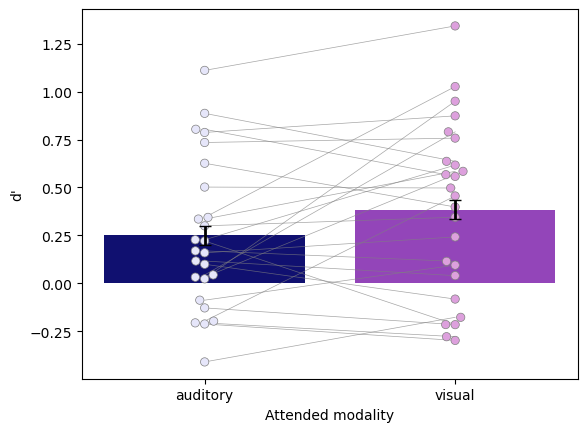

In [9]:
barplot_morey_simple(sdt_df, "modality", "d_prime", ["navy", "darkorchid"], ["lavender", "plum"], barplot_plot=True, swarmplot_plot=True, within_lines=True)
plt.ylabel("d'")
plt.xlabel("Attended modality")
dprime_results.summary()

/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/analyses/myFigures.py:195: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/analyses/myFigures.py:206: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


,F Value,Num DF,Den DF,Pr > F
modality,2.0163,1.0000,24.0000,0.1685


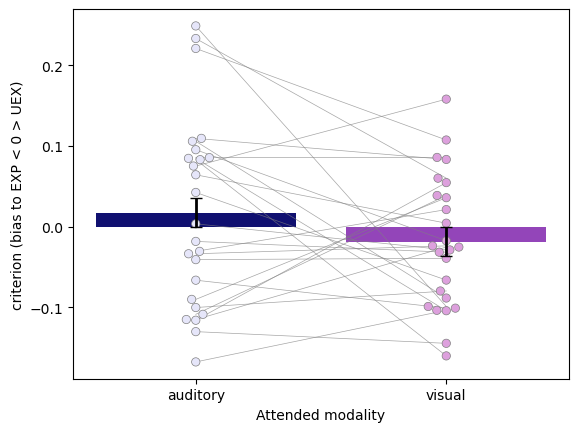

In [10]:
barplot_morey_simple(sdt_df, "modality", "criterion", ["navy", "darkorchid"], ["lavender", "plum"], barplot_plot=True, swarmplot_plot=True, within_lines=True)
plt.ylabel("criterion (bias to EXP < 0 > UEX)")
plt.xlabel("Attended modality")
criterion_results.summary()

## Cross-modal effects

In [11]:
# Compute visual d' and criterion for each subject by attention and auditory expectation.
sdt_df =compute_dprime(df, "signal_noise", ["modality", "a_pred"])

# two-way repeated measures ANOVA on d' and criterion
aov_dprime = AnovaRM(sdt_df, "d_prime", "subj", within=["modality", "a_pred"])
dprime_results = aov_dprime.fit()

aov_criterion = AnovaRM(sdt_df, "criterion", "subj", within=["modality", "a_pred"])
criterion_results = aov_criterion.fit()

# t-tests on d' and criterion
t_dprime = pg.pairwise_tests(data=sdt_df, dv="d_prime", within=["modality", "a_pred"], subject="subj", padjust="fdr_bh")
t_criterion = pg.pairwise_tests(data=sdt_df, dv="criterion", within=["modality", "a_pred"], subject="subj", padjust="fdr_bh")

/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/analyses/myFigures.py:172: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=hue, loc='upper left', bbox_to_anchor=(1, 1))


,F Value,Num DF,Den DF,Pr > F
modality,3.6182,1.0000,24.0000,0.0692
a_pred,0.5802,1.0000,24.0000,0.4537
modality:a_pred,2.4128,1.0000,24.0000,0.1334


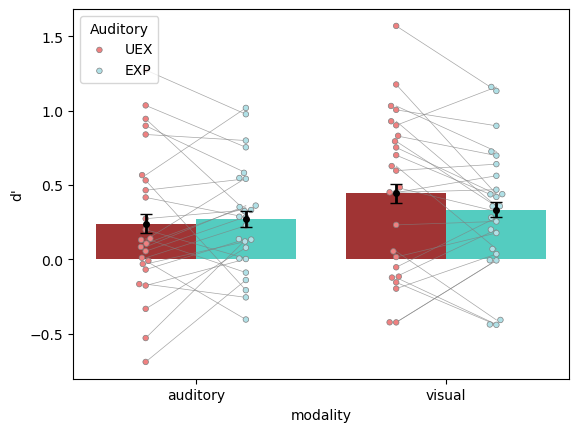

In [12]:
x = "modality"; y = "d_prime"; hue = "a_pred"
palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]

barplot_morey(sdt_df, x=x, y=y, hue=hue, palette1=palette1, palette2=palette2)
plt.ylabel("d'")

plt.legend(title="Auditory", loc="upper left", labels=["UEX", "EXP"])

#plt.savefig(f"figures/sdt/dprime_{ROI}.svg", dpi=300)
dprime_results.summary()

In [13]:
t_dprime

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-1.902151,24.0,two-sided,0.069219,NaN,NaN,0.994,-0.310005
1,a_pred,-,0,1,True,True,0.761683,24.0,two-sided,0.453670,NaN,NaN,0.274,0.095113
2,modality * a_pred,auditory,0,1,True,True,-0.445530,24.0,two-sided,0.659930,0.659930,fdr_bh,0.231,-0.072109
3,modality * a_pred,visual,0,1,True,True,1.655534,24.0,two-sided,0.110836,0.221671,fdr_bh,0.695,0.225820


/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/analyses/myFigures.py:172: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=hue, loc='upper left', bbox_to_anchor=(1, 1))


,F Value,Num DF,Den DF,Pr > F
modality,1.9767,1.0000,24.0000,0.1726
a_pred,0.8621,1.0000,24.0000,0.3624
modality:a_pred,2.2667,1.0000,24.0000,0.1452


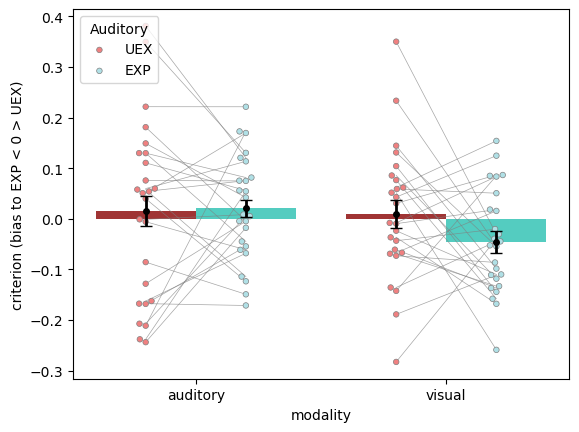

In [14]:
x = "modality"; y = "criterion"; hue = "a_pred"
palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]

barplot_morey(sdt_df, x=x, y=y, hue=hue, palette1=palette1, palette2=palette2)
plt.ylabel("criterion (bias to EXP < 0 > UEX)")

plt.legend(title="Auditory", loc="upper left", labels=["UEX", "EXP"])

#plt.savefig(f"figures/sdt/criterion_{ROI}.svg", dpi=300)
criterion_results.summary()

In [15]:
t_criterion

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,1.405953,24.0,two-sided,0.172553,NaN,NaN,0.505,0.344503
1,a_pred,-,0,1,True,True,0.928496,24.0,two-sided,0.362395,NaN,NaN,0.311,0.232888
2,modality * a_pred,auditory,0,1,True,True,-0.172352,24.0,two-sided,0.864606,0.864606,fdr_bh,0.214,-0.038453
3,modality * a_pred,visual,0,1,True,True,1.619550,24.0,two-sided,0.118396,0.236793,fdr_bh,0.662,0.454939


Visualize "signal" and "noise" distributions.

/tmp/ipykernel_29786/3200863298.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Visual"] = np.where(plot_df["signal_noise"] == "signal", "EXP", "UEX")
/tmp/ipykernel_29786/3200863298.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Visual"] = np.where(plot_df["signal_noise"] == "signal", "EXP", "UEX")
/tmp/ipykernel_29786/3200863298.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

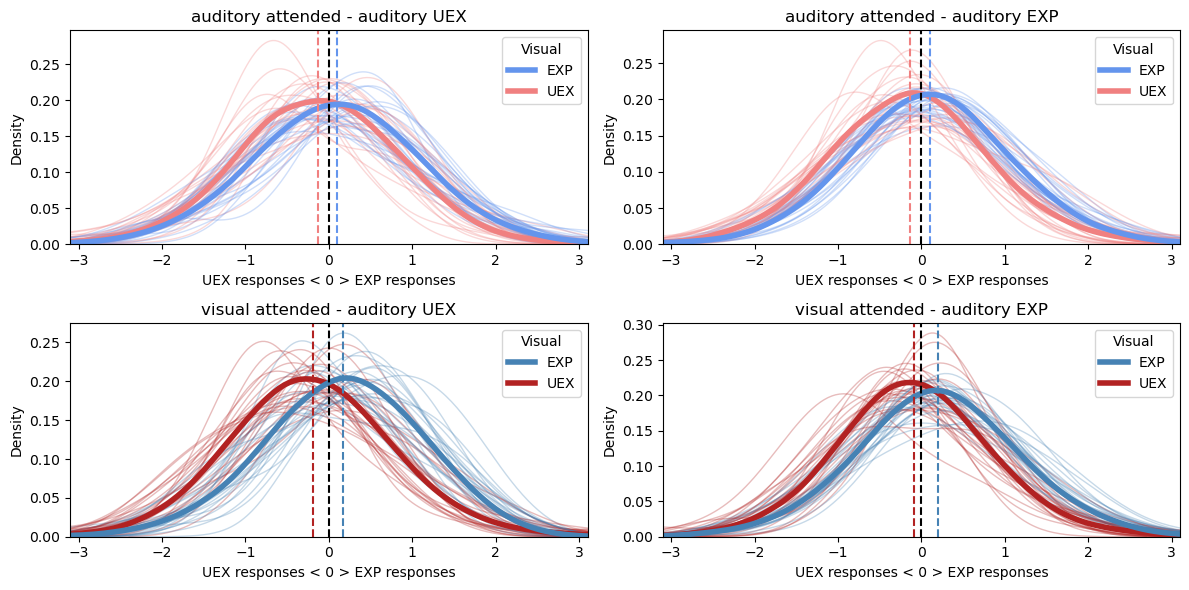

In [16]:
# Define a consistent color palette for EXP and UEX
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for i, modality in enumerate(["auditory", "visual"]):
    for j, a_pred in enumerate([0, 1]):
        plot_df = df[(df["modality"] == modality) & (df["a_pred"] == a_pred)]

        if modality == "visual":
            palette = {"EXP": "steelblue", "UEX": "firebrick"}
        else:
            palette = {"EXP": "cornflowerblue", "UEX": "lightcoral"}


        if a_pred == 1:
            pred_label = "EXP"
        else: 
            pred_label = "UEX"

        # Column for plotting legend
        plot_df["Visual"] = np.where(plot_df["signal_noise"] == "signal", "EXP", "UEX")
        
        # Plot individual KDE curves for each subject
        for subj in plot_df['subj'].unique():
            subj_data = plot_df[plot_df['subj'] == subj]
            sns.kdeplot(
                data=subj_data, 
                x="z_distance", 
                hue="Visual", 
                hue_order=["EXP", "UEX"],  # Fixed legend order
                palette=palette, 
                fill=False, 
                alpha=0.3,  # Make individual curves semi-transparent
                linewidth=1,  # Make individual lines thinner
                ax=axes[i, j],
                bw_adjust=2,  # Adjust bandwidth for smoother curves
                legend=False  # Disable legend for individual curves
            )

        # Add group-level KDE for comparison
        sns.kdeplot(
            data=plot_df, 
            x="z_distance", 
            hue="Visual", 
            hue_order=["EXP", "UEX"],  # Fixed legend order
            palette=palette, 
            fill=False, 
            ax=axes[i, j],
            bw_adjust=2,
            linewidth=4  # Make group-level lines thicker
        )

        # Calculate and add vertical lines for means
        signal_avg = plot_df[plot_df["signal_noise"] == "signal"]["z_distance"].mean()
        noise_avg = plot_df[plot_df["signal_noise"] == "noise"]["z_distance"].mean()
        axes[i, j].axvline(x=0, color="black", linestyle="--")
        axes[i, j].axvline(x=signal_avg, color=palette["EXP"], linestyle="--")
        axes[i, j].axvline(x=noise_avg, color=palette["UEX"], linestyle="--")
        axes[i, j].set_title(f"{modality} attended - auditory {pred_label}")
        axes[i, j].set_xlim([-3.1, 3.1])
        axes[i, j].set_xlabel("UEX responses < 0 > EXP responses")

# Adjust layout and show the plot
plt.tight_layout()
#plt.savefig(f"figures/sdt/{ROI}_dist.svg", dpi=300)


## Sanity checks

### Plot Hit and False Alarm rate

In [17]:
# Compute visual d' and criterion for each subject by attention and auditory expectation.
sdt_df =compute_dprime(df, "signal_noise", ["modality", "a_pred"])
# it is easier to plot the data if we transform the dataframe to long format
dat = pd.melt(sdt_df, id_vars=['subj', 'modality', 'a_pred'], 
                        value_vars=['hit_rate', 'fa_rate'], 
                        var_name='sdt', 
                        value_name='value')

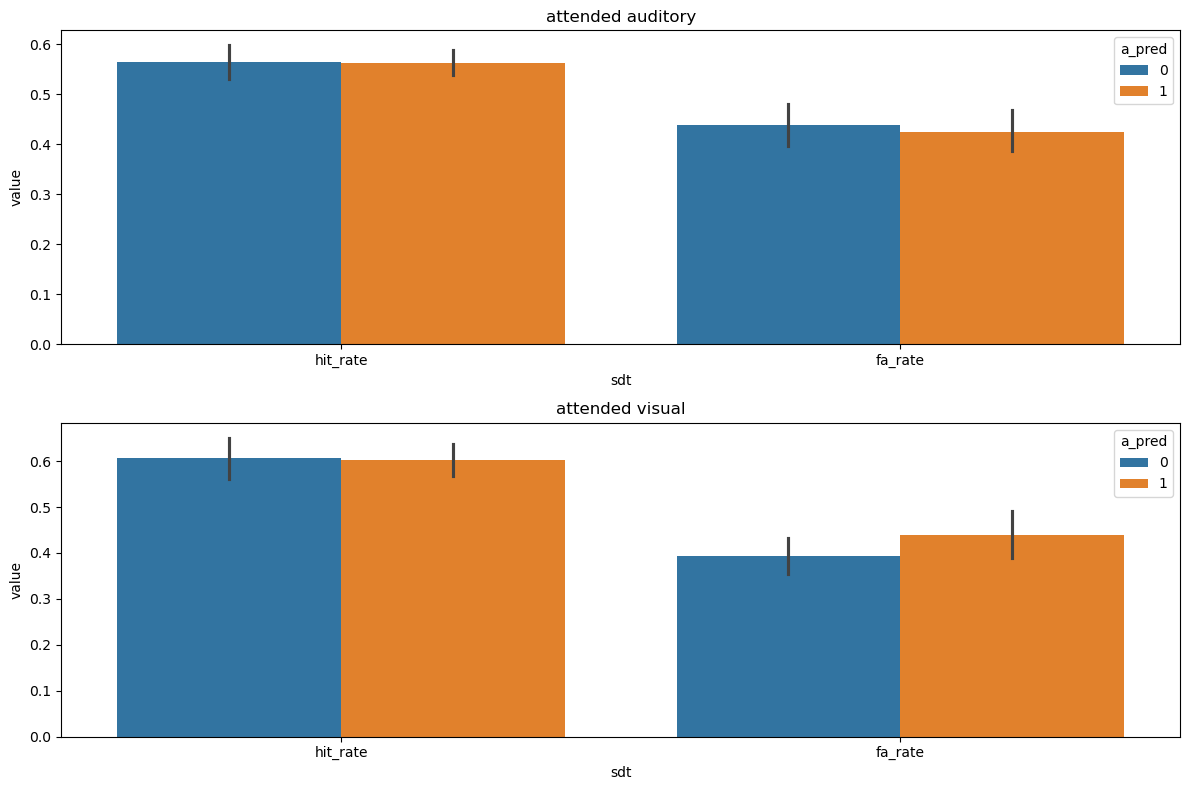

In [18]:
# Define a consistent color palette for EXP and UEX
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
#palette = {"hit": "mediumorchid", "fa": "limegreen", "miss": "gold", "CR": "darkorange"}
pred_labels = ["UEX", "EXP"]

for i, modality in enumerate(["auditory", "visual"]):

        plot_df = dat[(dat["modality"] == modality)]


        sns.barplot(
            data=plot_df, 
            x="sdt", 
            y="value", 
            hue="a_pred", 
            #palette=palette, 
            ax=axes[i]
        )

        # # Calculate and add vertical lines for means
        # signal_avg = plot_df[plot_df["signal_noise"] == "signal"]["z_distance"].mean()
        # noise_avg = plot_df[plot_df["signal_noise"] == "noise"]["z_distance"].mean()
        # axes[i, j].axvline(x=0, color="black", linestyle="--")
        # axes[i, j].axvline(x=signal_avg, color=palette["EXP"], linestyle="--")
        # axes[i, j].axvline(x=noise_avg, color=palette["UEX"], linestyle="--")
        axes[i].set_title(f"attended {modality}")
        # axes[i, j].set_xlim([-3.1, 3.1])
        # axes[i, j].set_xlabel("UEX responses < 0 > EXP responses")

# Adjust layout and show the plot
plt.tight_layout()
#plt.savefig(f"figures/sdt/{ROI}_dist.svg", dpi=300)

### Confirming if the results correspond to changes in criterion towards expected stimuli

In [23]:
df_sanity_checks = pd.read_csv(f"decoding_data/{ROI}_funcloc/balanced_group_data.csv")

df_sanity_checks["expected_stim"] = np.where(
    df_sanity_checks["v_pred"] == 1, 
    df_sanity_checks["labels"], 
    np.where(df_sanity_checks["labels"] == 45, 135, 45)
)

In [24]:
# Instead of jointly considering CW and CCW trials based on their expectedness,
# we will be considering them as signal and noise (arbitrarily) in order to confirm that the shift in criterion towards the expected stimuli
# corresponds to an actual shift towards the specific expected stimulus. This way we also make sure that the shift in criterion is observed towards only one of the two stimuli

df_sanity_checks["hit"] = np.where(
    (df_sanity_checks["correct"] == 1) & (df_sanity_checks["labels"] == 45), 1, 0
)

df_sanity_checks["fa"] = np.where(
    (df_sanity_checks["correct"] == 0) & (df_sanity_checks["labels"] == 135), 1, 0
)

df_sanity_checks["CR"] = np.where(
    (df_sanity_checks["correct"] == 1) & (df_sanity_checks["labels"] == 135), 1, 0
)

df_sanity_checks["miss"] = np.where(
    (df_sanity_checks["correct"] == 0) & (df_sanity_checks["labels"] == 45), 1, 0

)

# Alternatively, code decision type in a single column
df_sanity_checks["decision_type"] = np.where(
    (df_sanity_checks["correct"] == 1) & (df_sanity_checks["labels"] == 45), "hit",
    np.where(
        (df_sanity_checks["correct"] == 0) & (df_sanity_checks["labels"] == 135), "fa",
        np.where(
            (df_sanity_checks["correct"] == 1) & (df_sanity_checks["labels"] == 135), "CR",
            np.where(
                (df_sanity_checks["correct"] == 0) & (df_sanity_checks["labels"] == 45), "miss",
                "error"
            )
        )
    )
)

# New column for signal and noise trials
df_sanity_checks["signal_noise"] = np.where(
    (df_sanity_checks["decision_type"] == "hit") | (df_sanity_checks["decision_type"] == "miss"), "signal",
    np.where(
        (df_sanity_checks["decision_type"] == "fa") | (df_sanity_checks["decision_type"] == "CR"), "noise",
        "error"
    )
)

df_CW = df_sanity_checks[df_sanity_checks["expected_stim"] == 45]
df_CCW = df_sanity_checks[df_sanity_checks["expected_stim"] == 135]



### Global test

In [25]:
# Compute visual d' and criterion for each subject by attention and auditory expectation.
sdt_df_CW =compute_dprime(df_CW, "signal_noise", ["modality"])
sdt_df_CCW =compute_dprime(df_CCW, "signal_noise", ["modality"])

sdt_df_CW["expected_stim"] = 45
sdt_df_CCW["expected_stim"] = 135

dat_simple = pd.concat([sdt_df_CW, sdt_df_CCW])

dprime_results = AnovaRM(dat_simple, "d_prime", "subj", within=["modality", "expected_stim"]).fit()
criterion_results = AnovaRM(dat_simple, "criterion", "subj", within=["modality", "expected_stim"]).fit()


,F Value,Num DF,Den DF,Pr > F
modality,3.6741,1.0000,23.0000,0.0678
expected_stim,0.4270,1.0000,23.0000,0.5200
modality:expected_stim,0.0123,1.0000,23.0000,0.9128


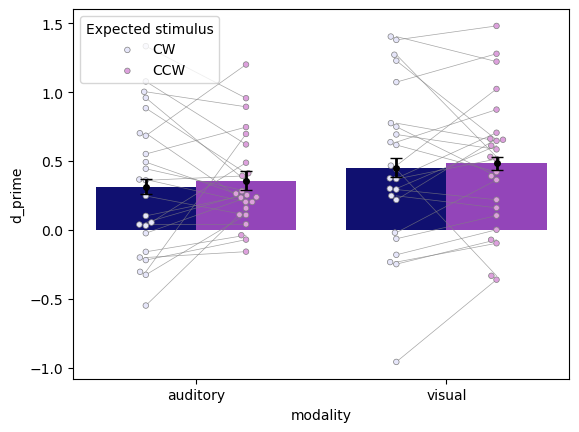

In [26]:
barplot_morey(dat_simple, "modality", "d_prime", "expected_stim", ["navy", "darkorchid"], ["lavender", "plum"], barplot_plot=True, swarmplot_plot=True, within_lines=True)
plt.legend(title="Expected stimulus", loc="upper left", labels=["CW", "CCW"])
dprime_results.summary()

,F Value,Num DF,Den DF,Pr > F
modality,3.6741,1.0000,23.0000,0.0678
expected_stim,0.4270,1.0000,23.0000,0.5200
modality:expected_stim,0.0123,1.0000,23.0000,0.9128


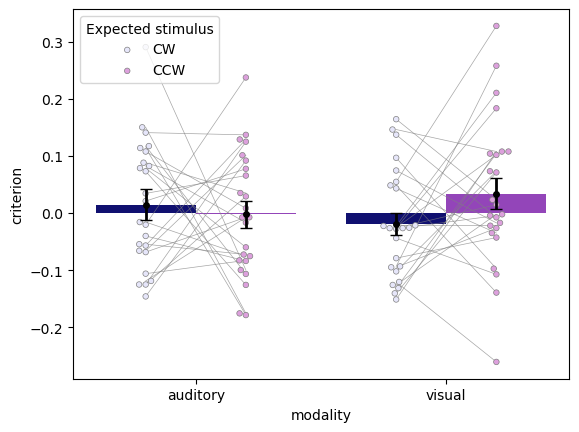

In [27]:
barplot_morey(dat_simple, "modality", "criterion", "expected_stim", ["navy", "darkorchid"], ["lavender", "plum"], barplot_plot=True, swarmplot_plot=True, within_lines=True)
plt.legend(title="Expected stimulus", loc="upper left", labels=["CW", "CCW"])
dprime_results.summary()

### By modality and auditory prediction

In [28]:
# Compute visual d' and criterion for each subject by attention and auditory expectation.
dat_CW =compute_dprime(df_CW, "signal_noise", ["modality", "a_pred"])
dat_CW["expected_stim"] = "CW"
dat_CCW =compute_dprime(df_CCW, "signal_noise", ["modality", "a_pred"])
dat_CCW["expected_stim"] = "CCW"
dat = pd.concat([dat_CW, dat_CCW])

/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/MVPA_proba/analyses/myFigures.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/MVPA_proba/analyses/myFigures.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/MVPA_proba/analyses/myFigures.py:91

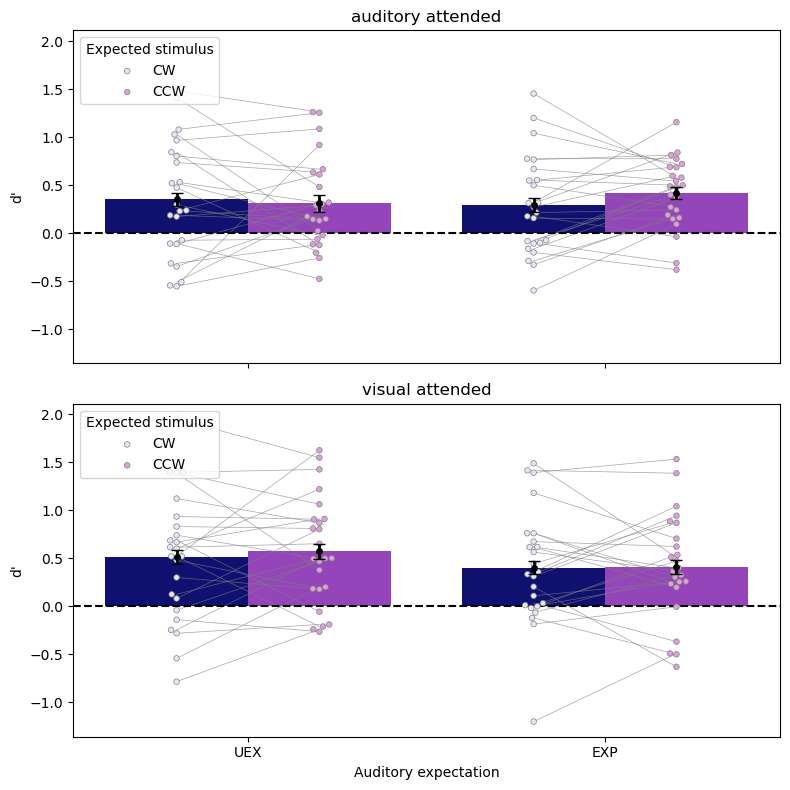

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharey=True, sharex=True)
for i, modality in enumerate(["auditory", "visual"]):
    plot_df = dat[(dat["modality"] == modality)]

    
    barplot_morey(plot_df, "a_pred", "d_prime", "expected_stim", ["navy", "darkorchid"], ["lavender", "plum"], barplot_plot=True, swarmplot_plot=True, within_lines=True, ax=axes[i])


    
    # Format the title with F and p values
    axes[i].set_title(f"{modality} attended")

    axes[i].axhline(y=0, color="black", linestyle="--")
    axes[i].set_xlabel("Auditory expectation")
    axes[i].set_ylabel("d'")
    axes[i].set_xticklabels(["UEX", "EXP"])
    axes[i].legend(title="Expected stimulus", loc="upper left", labels=["CW", "CCW"])

# Adjust layout and show the plot
plt.tight_layout()


In [30]:
pg.rm_anova(data=dat[dat["modality"]=="visual"], dv="d_prime", within=["a_pred", "expected_stim"], subject="subj")

/home/wiseman/miniconda3/envs/pymer4/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/wiseman/miniconda3/envs/pymer4/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,a_pred,0.448278,1,23,0.448278,3.402136,0.078031,0.078031,0.013306,1.0
1,expected_stim,0.027021,1,23,0.027021,0.185033,0.671087,0.671087,0.000812,1.0
2,a_pred * expected_stim,0.017301,1,23,0.017301,0.146461,0.705454,0.705454,0.000520,1.0


In [31]:
pg.pairwise_tests(data=dat[dat["modality"]=="visual"], dv="d_prime", within=["a_pred", "expected_stim"], subject="subj", padjust="fdr_bh")

,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,a_pred,-,0,1,True,True,1.844488,23.0,two-sided,0.078031,NaN,NaN,0.921,0.247379
1,expected_stim,-,CCW,CW,True,True,0.430155,23.0,two-sided,0.671087,NaN,NaN,0.234,0.060372
2,a_pred * expected_stim,0,CCW,CW,True,True,0.554693,23.0,two-sided,0.584459,0.947523,fdr_bh,0.247,0.095907
3,a_pred * expected_stim,1,CCW,CW,True,True,0.066539,23.0,two-sided,0.947523,0.947523,fdr_bh,0.215,0.011329


/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/MVPA_proba/analyses/myFigures.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/MVPA_proba/analyses/myFigures.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
/media/wiseman/tocho/predrelv_fmri/group_analyses/multivariate/MVPA_proba/analyses/myFigures.py:91

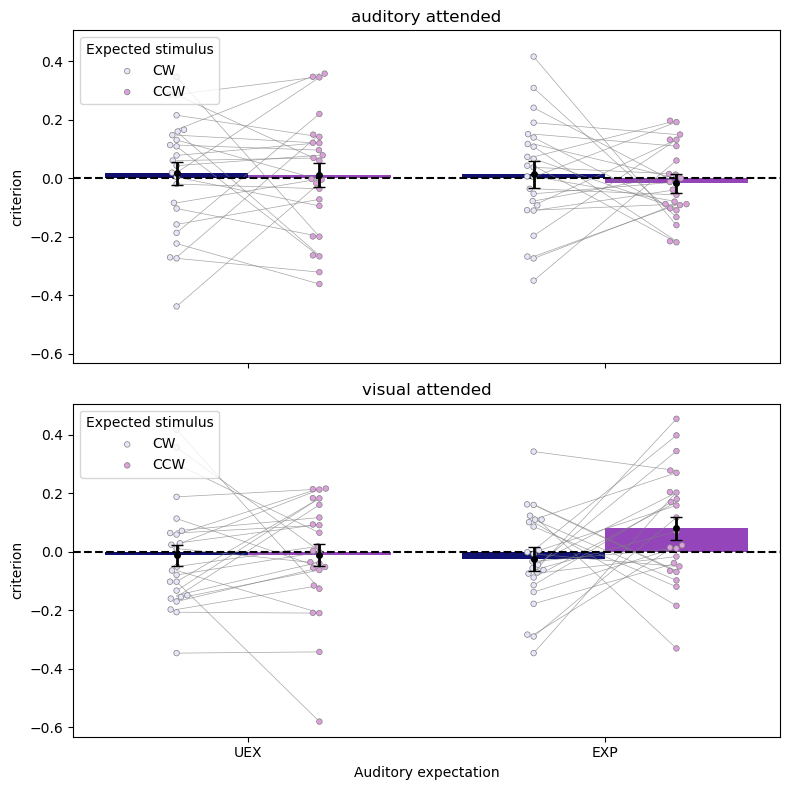

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharey=True, sharex=True)
for i, modality in enumerate(["auditory", "visual"]):
    plot_df = dat[(dat["modality"] == modality)]

    
    barplot_morey(plot_df, "a_pred", "criterion", "expected_stim", ["navy", "darkorchid"], ["lavender", "plum"], barplot_plot=True, swarmplot_plot=True, within_lines=True, ax=axes[i])


    
    # Format the title with F and p values
    axes[i].set_title(f"{modality} attended")

    axes[i].axhline(y=0, color="black", linestyle="--")
    axes[i].set_xlabel("Auditory expectation")
    axes[i].set_ylabel("criterion")
    axes[i].set_xticklabels(["UEX", "EXP"])
    axes[i].legend(title="Expected stimulus", loc="upper left", labels=["CW", "CCW"])

# Adjust layout and show the plot
plt.tight_layout()


In [33]:
pg.rm_anova(data=dat[dat["modality"]=="visual"], dv="criterion", within=["a_pred", "expected_stim"], subject="subj")

/home/wiseman/miniconda3/envs/pymer4/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/wiseman/miniconda3/envs/pymer4/lib/python3.9/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,a_pred,0.037218,1,23,0.037218,0.825305,0.373055,0.373055,0.011903,1.0
1,expected_stim,0.066236,1,23,0.066236,2.346724,0.139187,0.139187,0.020989,1.0
2,a_pred * expected_stim,0.065267,1,23,0.065267,1.918406,0.179321,0.179321,0.020688,1.0


In [34]:
pg.pairwise_tests(data=dat[dat["modality"]=="visual"], dv="criterion", within=["a_pred", "expected_stim"], subject="subj", padjust="fdr_bh")

,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,a_pred,-,0,1,True,True,-0.908463,23.0,two-sided,0.373055,NaN,NaN,0.311,-0.288549
1,expected_stim,-,CCW,CW,True,True,1.531902,23.0,two-sided,0.139187,NaN,NaN,0.598,0.439838
2,a_pred * expected_stim,0,CCW,CW,True,True,0.008424,23.0,two-sided,0.993352,0.993352,fdr_bh,0.215,0.002003
3,a_pred * expected_stim,1,CCW,CW,True,True,1.883434,23.0,two-sided,0.072348,0.144696,fdr_bh,0.975,0.582391
